# Architectures for diverse problem domains


As we saw in previous sessions, deep learning is about creating compressed representations of our D-dimensional input in an N-dimensional space where usually N << D. Then, in that space, the model is capable of differentiating the instances of our dataset.

For this session, let's properly define some concepts:

- **Feature extraction**: dimensionality reduction process that transforms raw, high-dimensional, complex data into a simplified, manageable set of meaningful features (vectors) while *retaining key information*.

When we talk about the architecture of a model, it is divided in two parts:
- **Backbone (Encoder)**: this is the part that does the feature extraction, the part that transforms the high-dimensional data into a compressed representation while keeping the important information. These representations populate what is called the *latent space*.
- **Head (Decoder)**: this is the part that performs the final decision, the part that performs the task at hand. It decides for the final classification of the input, predicts the value of regression, etc., given the compressed representation of the input.

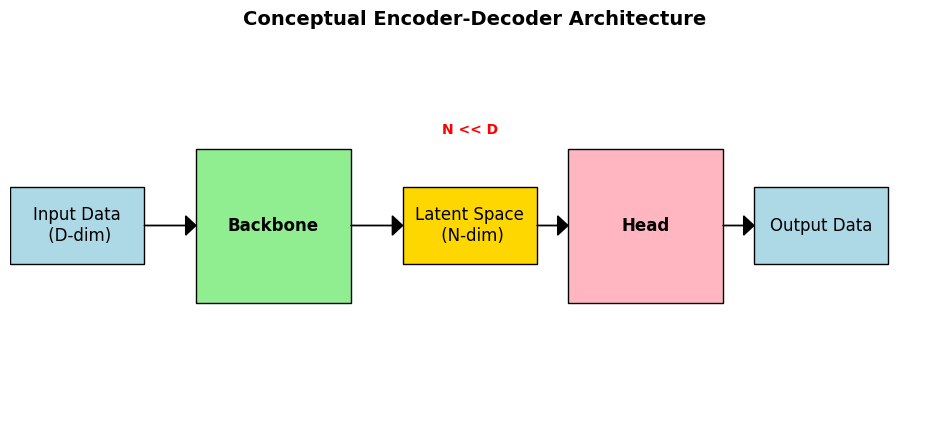

In [ ]:
# @title
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 5)) # Increased figure width for better spacing

# Define rectangle widths and gaps
input_width = 1.3
encoder_width = 1.5
latent_width = 1.3
decoder_width = 1.5
output_width = 1.3

gap1 = 0.5 # Gap between Input and Encoder
gap2 = 0.5 # Gap between Encoder and Latent
gap3 = 0.3 # Gap between Latent and Decoder
gap4 = 0.3 # Gap between Decoder and Output

# Input Data
input_x = 0
input_rect = patches.Rectangle((input_x, 0.4), input_width, 0.2, facecolor='#ADD8E6', edgecolor='black', linewidth=1)
ax.add_patch(input_rect)
ax.text(input_x + input_width/2, 0.5, 'Input Data\n (D-dim)', ha='center', va='center', fontsize=12)

# Encoder
encoder_x = input_x + input_width + gap1
encoder_rect = patches.Rectangle((encoder_x, 0.3), encoder_width, 0.4, facecolor='#90EE90', edgecolor='black', linewidth=1)
ax.add_patch(encoder_rect)
ax.text(encoder_x + encoder_width/2, 0.5, 'Backbone', ha='center', va='center', fontsize=12, fontweight='bold')

# Compressed Representation / Latent Space
latent_x = encoder_x + encoder_width + gap2
latent_rect = patches.Rectangle((latent_x, 0.4), latent_width, 0.2, facecolor='#FFD700', edgecolor='black', linewidth=1)
ax.add_patch(latent_rect)
ax.text(latent_x + latent_width/2, 0.5, 'Latent Space\n (N-dim)', ha='center', va='center', fontsize=12)

# Decoder
decoder_x = latent_x + latent_width + gap3
decoder_rect = patches.Rectangle((decoder_x, 0.3), decoder_width, 0.4, facecolor='#FFB6C1', edgecolor='black', linewidth=1)
ax.add_patch(decoder_rect)
ax.text(decoder_x + decoder_width/2, 0.5, 'Head', ha='center', va='center', fontsize=12, fontweight='bold')

# Output Data
output_x = decoder_x + decoder_width + gap4
output_rect = patches.Rectangle((output_x, 0.4), output_width, 0.2, facecolor='#ADD8E6', edgecolor='black', linewidth=1)
ax.add_patch(output_rect)
ax.text(output_x + output_width/2, 0.5, 'Output Data', ha='center', va='center', fontsize=12)

# Arrows
ax.arrow(input_x + input_width, 0.5, gap1 - 0.1, 0, head_width=0.05, head_length=0.1, fc='black', ec='black')
ax.arrow(encoder_x + encoder_width, 0.5, gap2 - 0.1, 0, head_width=0.05, head_length=0.1, fc='black', ec='black')
ax.arrow(latent_x + latent_width, 0.5, gap3 - 0.1, 0, head_width=0.05, head_length=0.1, fc='black', ec='black')
ax.arrow(decoder_x + decoder_width, 0.5, gap4 - 0.1, 0, head_width=0.05, head_length=0.1, fc='black', ec='black')

# Text for N << D
ax.text(latent_x + latent_width/2, 0.75, 'N << D', ha='center', va='center', fontsize=10, color='red', fontweight='bold')

ax.set_xlim(0, output_x + output_width + 0.5) # Adjust xlim to fit all elements
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Conceptual Encoder-Decoder Architecture', fontsize=14, fontweight='bold')

plt.show()

So, of course, depending on the type of input data that we have, we are going to use different **feature extractors** in the Encoder.

Until now, we have seen that an MLP can be enough for tabluar data; if the tabular data is complex, we only need to add more hidden layers and increase the network's abstraction capabilities. But what happens when the input is an image? A graph? A signal?

## Convolutional Neural Network (CNN)



We could try to pass an image to an MLP. Each pixel value is assigned to each of the input neurons. From there, we let it learn to classify or whatever the task at hand is.

But it would not lead to good results. Images have certain characteristics that we could leverage to train a model, but that are completely lost when we pass each pixel individually to an MLP:

- **High Localized Spatial Correlation (Pixel Neighborhoods)**: nearby pixels are strongly correlated; they usually belong to the same object or to an edge that marks the difference between two objects. With an MLP, we loose all relative spatial information, since the pixels are presented as a list, not a matrix.
- **Translational Invariance**: in an image, an object can appear at the center, at the top-left or at the bottom-right. The same can be said for the size of said object; due to perspective, the object can appear to be bigger or smaller depending on their distance to the camera. In MLPs, each input will always be interpreted in the same position, so it would not be capable of identifying the same thing in different places.
- **High-Dimensionality**: a standard color image (224x224x3) has roughly 150,000 values. For an image that small, an MLP with a 1,000 neurons in the first hidden layer would require 150,000,000 trainable weights for a single layer. There is a *parameter explosion*.

How do we solve all of this?

### The Convolution: the feature extractor for images and how do we build the Backbone

In [ ]:
from IPython.display import Image, display

url = "https://upload.wikimedia.org/wikipedia/commons/1/19/2D_Convolution_Animation.gif"
display(Image(url=url, width=500))

The convolution is the feature extraction process of CNNs. A small matrix (kernel/filter) slides across the image to detect features like edges or textures. Translating from the MLP concepts:

- **Weights**: the weights are now the elements of the kernel. That is what the CNN is going to be changing and learning during training.
- **Hidden layer**: now, a layer is composed of several kernels, all of them the same size and similar configuration. We will see how they can be configured in PyTorch later.

So, since the objective is to create compressed representations of the input, the classical CNNs looked like this:

In [ ]:
from IPython.display import Image, display

url = "https://viso.ai/wp-content/uploads/2024/04/alexNet-architecture.png"
display(Image(url=url, width=1000))

Another translation to understand fully how the compressed representation is achieved:
- **Activation functions and other non-linearities**: activation functions are still present; they are also applied to the results of the convolution. However, we can also introduce non-linearities like **pooling**, where we reduce the size by a half by making an operation such as maximum, minimum or average.  

In [ ]:
# @title
from IPython.display import Image, display

url = "https://www.researchgate.net/publication/355020694/figure/fig6/AS:1106343318560779@1640784210906/Max-pooling-vs-average-pooling.png"
display(Image(url=url, width=500))

Combining these things, we can get a set of compressed features at the end of the decoder. With an operation like **flattening** the feature maps or a **global average pooling** (reduces each feature map to a single scalar by calculating the mean of its values), we get the compressed representation of the input.

In [ ]:
# @title
from IPython.display import Image, display

url = "https://www.researchgate.net/publication/339096868/figure/fig2/AS:11431281391083351@1745306731973/Difference-between-fully-connected-layer-and-global-average-pooling-layer.tif"
display(Image(url=url, width=1000))

### The task at hand: how do we develop the Head for CNNs.

Depending on what our purpose is with the images, we can tune the architecture of our decoder. This is true for all types of data.

#### Classification

When we are performing image classification &mdash; that is classifying an entire image into a single category &mdash; the process is simple: we take the compressed representation and run it through an MLP. At the end, we have a vector of probabilities, with as many values as possible classes there are in our dataset. For example, the standard [ImageNet](https://www.image-net.org/) dataset has 1,000 object classes, such as "goldfish", "hen", "beer glass", etc. We would have a head that transforms that representation into a vector of 1,000 values.

#### Object detection

Object detection refers to the task of signaling where in the image is a specific class:

In [ ]:
# @title
from IPython.display import Image, display

url = "https://framerusercontent.com/images/mht2qZxRPtVYBF7hPYq8cOTsfQc.png"
display(Image(url=url, width=500))

As you can see, there are actually two tasks at display: the first one would be to find where in the image an object is (we call this a **bounding box**) and the second in is to identify what that object is.

Different models do it in different ways, some having a head for each task (one for the regression of coordinates of the bounding box and another for classification, such as [Fast R-CNN](https://arxiv.org/abs/1504.08083)) and some do it all at the same time (such as [YOLO](https://arxiv.org/abs/1506.02640)).

The maths behind are a bit more complex. Check them out if you are interested!

In [ ]:
# @title
from IPython.display import Image, display

url = "https://www.researchgate.net/publication/361318482/figure/fig4/AS:1172321196867586@1656514562986/Structure-of-Fast-R-CNN-head-for-object-detection.ppm"
display(Image(url=url, width=500))

#### Segmentation

Segmentation is similar to object detection, but instead of using a bounding box, we select the pixels for each class:

In [ ]:
# @title
from IPython.display import Image, display

url = "https://media.geeksforgeeks.org/wp-content/uploads/20250822165608750974/panoptic-segmentation.webp"
display(Image(url=url, width=500))

Since the output is a pixel by pixel classification, it means that we have another image as the output. In fact, we have an image with as many channels as classes there are. There are also different approaches:

- **[Fully Convolutional Networks](https://www.computer.org/csdl/journal/tp/2017/04/07478072/13rRUxly96M)**: this was one of the first approaches, where they substituted the MLP at the end of a classification network for more convolutions. Because of that, we get the network to output a spatial map that is rapidly upsampled. Similar approaches were taken with [DialatedNet](https://arxiv.org/abs/1511.07122) and [DeepLab](https://arxiv.org/abs/1606.00915).

In [ ]:
# @title
from IPython.display import Image, display

url = "https://csdl-images.ieeecomputer.org/trans/tp/2017/04/figures/shelh1-2572683.gif"
display(Image(url=url, width=500))

- **Convolution-Deconvolution networks**: this networks mirrored in the Decoder part of the network what the Encoder did, with deconvolution layers, un-pooling and some other techniques to upsample the compressed input. We have [Deconvnet](https://arxiv.org/abs/1505.04366), [U-Net](https://arxiv.org/abs/1505.04597), [SegNet](https://arxiv.org/abs/1511.00561)... There are many.

In [ ]:
# @title
from IPython.display import Image, display

print("Deconvnet")
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTMna8NY3718n6URChCJXmLC_gS4H6oNcXDXA&s"
display(Image(url=url, width=600))
print("U-Net")
url = "https://liora.io/app/uploads/sites/7/2021/05/u-net-architecture-1024x682.png"
display(Image(url=url, width=500))

Deconvnet


U-Net


## Graph Neural Networks (GNN)

Most of the topics presented here are extracted from [Introduction to Graph Neural Networks: A Starting Point for Machine Learning Engineers](https://arxiv.org/abs/2412.19419).

These types of Neural Networks are designed for graphs whose nodes or edges have attributes. This can go from internet searches to molecules.

Common applications are:

- Node classification: assign a class to a specific node of the graph.
- Link prediction: predict if an edge exists between two nodes.
- Community detection: the goal is to cluster the nodes of the graph into groups, using a similarity measure.
- Node regression and edge regression: predicting a numeric descriptor that is assigned to nodes or edges.
- Graph classification and graph regression: given a whole graph, representing some real-world entity, we classify it in a class or predict one or more descriptors in a regression.

Graphs are represented with their adjacency matrix:

$$A = (A_{ij}), \space i, j \in \mathcal{N}$$




### Encoder-decoder in GNN

#### Encoder


As we have seen repeatedly, the purpose of the encoder is to perform feature extraction in the input. The representation of the graph is similar to the image, but without the inherent characteristics we have discussed natural images have. When it comes to the GNN encoder, we can have three types of layers:



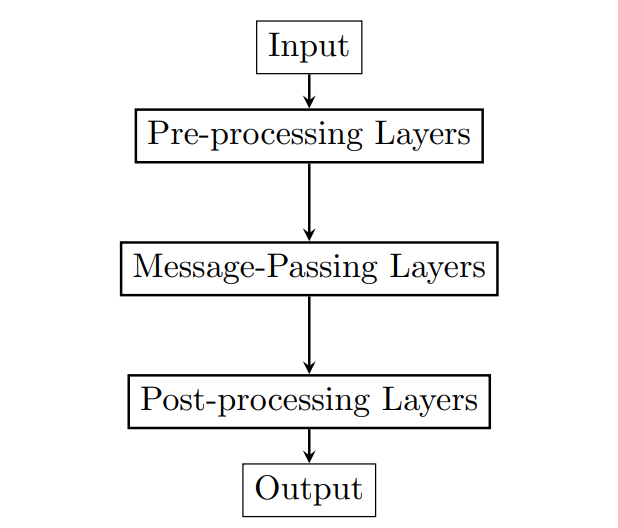

The pre-processing layers are just MLPs. They map each node attribute vector $x_i$ to a node feature vector $\tilde{x}_i$ in a computation that *does not involve the edges of the graph*.

$$\operatorname{Pre-proc}(x_i) = \tilde{x}_i$$

Their purpose is to perform feature extraction from the nodes.

Then, we have the message-passing layers. If $A$ is a graph with a matrix of node features $\tilde{X} = (\tilde{x}_i)_{i\in \mathcal{N}}$, the message-passing layer is a map:

$$\text{Message-passing} : (\tilde{X}, A) \rightarrow (H, A)$$

We go from graph $A$ with node features $\tilde X$ to the graph $A$ with node features $H = (h_i)_{i \in \mathcal{N}}$, where the node feature vectors $h_i$ are obtained by aggregating information from each node's neighborhood. The formula for these is the following:

$$h^{(k+1)}_i = \Phi (\bigwedge (h^{(k)}_i, \bigoplus_{j \in \mathcal{N}_i}\mu_{ij}) )$$

Let's look at it from the inside to the outside:

- $\mu_{ij}$ is a feature vector that describes the interaction of node $i$ with node $j$. This feature vector is the result of an operation we can define using the feature vectors of both nodes $h^{(k)}_i$ and $h^{(k)}_j$. In fact, however we define this relationship is how we will categorize the type of GNN we are working with: Convolutional, Message Passing (MP) or Attentional. But it is just that, a feature vector that relates our current feature vector with the feature vectors of the neighbors.
- $\bigoplus$ is just a permutation-invariant aggregation function. Something like element-ise vector-value sum, mean or maximum.
- $\mathcal{N}_i$ is the 1-hop neighborhood of $i$. We are looking only at direct neighbors of $i$.
- $\bigwedge$ determines how each node interacts with the aggregation of its neighbors (concatenation or element-wise summation).
- $\Phi$ is usually another MLP.

And then, post-processing layers follow the same pattern as pre-processing ones:

$$\operatorname{Post-proc}(h_i) = z_i$$

#### Decoder

To define the decoders, we have to look at the task at hand. The approaches here are very similar to what we have seen before:

- Node classification: make last post-processing layer output $z_i \in \mathbb{R}^C$, final feature vector for node $i$ with a dimension $C$, which is the number of possible classes, pass it through the Softmax function to get probabilities, and compare it with ground truth $y_i \in \mathbb{R}^C$, vector of all 0s and a 1 for the class of the node.
- Link prediction: take the feature vectors $z_i, z_j$ for vectors $i, j$, do scalar product between them and use the sigmoid function go get a value between 0 and 1 (probability of link existing between them).
- Graph classification: same as node classification but with an additional step. Apply a global aggregator for all feature vectors $z_i$, and produce a final, single feature vector for the entire graph.
- Community detection: we define a measure of divergence between the different clustered sections.
- Node regression: very similar to node classification, defining a single value as the output and defining a distance loss between ground truth and prediction.

## Physics-Informed Neural Networks (PINN)

The concept behind these types of networks is very simple: we want to embed the knowledge of physical laws that can be described by partial differential equations in the learning process.

**We do it by adding an extra regularization term to the Loss function; if the model is not following the restrictions established by physical loss, penalize it**.

They were first presented at [Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations](https://www.sciencedirect.com/science/article/abs/pii/S0021999118307125). The ideas explained here come from there.

Let's suppose you want your model to predict $u_t$, which is a solution restricted by the following partial differential equation:

$$u_t + \mathcal{N}[u;\lambda] = 0, \space x \in \Omega, \space t \in [0, T],$$

where $u(t,x)$ denotes the latent solution, $\mathcal{N}[·;\lambda]$ is a nonlinear differential operator parametrized by $\lambda$, and $\Omega$ is a subset of $\mathbb{R}^D$. This setup includes a wide range of problems in mathematical physics.

Our available data are the $t_u, x_u$ points and their corresponding prediction $u_t$ and ground truth $u$. However, we do not have enough data to train a robust model.

What we do is generate what is called *collocation points*, which is a set of $t_f,x_f$ points artificially generated by us which will have the corresponding output $u_f$.

This way, we define two terms:
- Data term: the type of loss we have seen until now, calculating a difference between the expected ground truth $u$ and the model's predictin $u_t$ with inputs $t_u, x_u$

$$L_u = \frac{1}{N_u} \sum^{N_u}_{i=1}{L_D(u^i_t, u^i)}$$

- Physics-informed term: calculated only with the collocation points, making sure they are being restricted by the partial differential equation

$$L_p = \frac{1}{N_f} \sum^{N_f}_{i=1}{|u_f + \mathcal{N}[u_f; \lambda]|^2}$$


In this manner, we are teaching our model to predict our data and following the restrictions the partial differential equation imposes on the system. Our final loss function would be:

$$L = L_u + L_f$$

## Auto-encoders

Autoencoders are a very specific type of neural network. They are used with the purpose of training a network that can capture the key aspects of the input data, to create a faithful compressed representation of it.



In [ ]:
# @title
from IPython.display import Image, display

url = "https://media.geeksforgeeks.org/wp-content/uploads/20251007093708285354/nueral.webp"
display(Image(url=url, width=600))

The main difference between these and other neural networks is that the other ones learn compressed representations that are useful for the task at hand; the latent space where the internal representations are is useful to separate into the classes we are going to classify the data in or to predict the regression value at hand. In the case of the autoencoders, the purpose is to be able to differentiate all input data individually.

How do we achieve this? How are they trained?

We train them in an **unsupervised manner**. This means there are no labels: no classes to classify the data, no value for regression.

The point is to reconstruct the input as faithfully as possible, a process that is called **lossless compression**.

That is why the encoder and the decoder are mirrored versions of each other, in these cases. The loss function is a similarity function between the output of the network and the input itself.

### Downstream tasks

The purpose of training autoencoders is to later dedicate the encoder part of it to a downstream task, which are the tasks we have seen since the beginning (classification, regression, etc.)

We do it when we have a lot of data, but most of it is not labeled for the task at hand: we have a lot of images of cats and dogs, but we have not put the work to actually label which ones are cats and which ones are dogs. We train an autoencoder to learn internal representations that faithfully represent the input and, after it has learned them, we:
- Take the Encoder part of the network.
- Change the Decoder to perform classification in two classes.
- Train again the Decoder part of the network, freezing the layers of the Encoder.

We can also train them directly for specific tasks.

#### Restoration

The Autoencoder is provided a damaged input, and its task is to reconstruct the clean input. The input could be the signal with noise or blur, not whitebalanced or very dark in the case of images, etc. Again, a similarity function between the clean input and the output of the network is used.

In [2]:
# @title
from IPython.display import Image, display

url = "https://media.geeksforgeeks.org/wp-content/uploads/20240107093422/DAE.jpeg"
display(Image(url=url, width=600))

## Transformers

This type of architecture, the Transformer, is what has led to the current AI boom era. And they did it thanks to one key operation: **attention**.

### Recurrent Neural Networks

First, we need to introduce Recurrent Neural Networks. The purpose of these networks is to predict the next time-step (e.g. a value, vector, etc.) in a time series. Something like the capacity of a battery after N cycles, the temperature of tomorrow given the temperatures of the last month, or even the next word in a text.

The original idea behind them was to keep a hidden state $h_t$ that is used as the memory that keeps information from the previous states.

In [3]:
# @title
from IPython.display import Image, display

url = "https://miro.medium.com/1*ccHxugJhQo7VH4GAAZt3Sg.png"
display(Image(url=url, width=600))

The problem with this structure is that the gradients the network saw in the early parts of the sample vanish very quickly (e.g. the network forgets the beginning of a long sentence).

There were some attempts at solving this issue while keeping the core idea behind them still, like [Long Short-Term Memory (LSTM)](https://ieeexplore.ieee.org/abstract/document/6795963), which introduced a gated architecture that was able to keep some longer term information for the early aspects of the sample, or [Gated Recurrent Units (GRU)](https://aclanthology.org/D14-1179.pdf), which is a simplified version of LSTM.

In [4]:
# @title
from IPython.display import Image, display

url = "https://d2l.ai/_images/lstm-3.svg"
display(Image(url=url, width=600))

However, they still found the same problems when the sequences became longer.

### Attention is all you need

Vaswani, A. et al's [*Attention is all you need*, ](https://arxiv.org/abs/1706.03762) is the paper that introduced the attention mechanism to the world.

Until then, as we have seen, all information was being compressed into a fading memory state that was only capable of retaining what was provided by the latest inputs. Attention allows the model to look back at every element in the sequence simultaneously and understand how they relate to each other. The model is capable of capture the intrinsic relationships despite the distance it might exist between the elements.




In [8]:
# @title
from IPython.display import Image, display

url = "https://miro.medium.com/v2/resize:fit:874/0*e4sPatjxrCSjdFk_.png"
display(Image(url=url, width=600))


How?

It works like a search engine. We have queries, keys and values ($Q, K, V$). In a search engine, $Q$ is the thing you are looking for, $K$ is the location where you can find it, and $V$ is the information contained in your database.

The mechanism calculates a compatibility score between $Q$ and all $K$ (the score is high if the compatibility is high), and then calculates a weighted average of $V$ based on that score.

$$\text{Attention}(Q, K, V) = \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V$$

This mechanism is at the center of the transformer architecture.

In [9]:
# @title
from IPython.display import Image, display

url = "https://media.geeksforgeeks.org/wp-content/uploads/20251004125140134507/transformers.webp"
display(Image(url=url, width=600))